In [1]:
# load libs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Load phenotype data (already done)
pheno = pd.read_csv("../data/final_dataset/height_adj.txt", delim_whitespace=True, header=None, names=["FID", "IID", "Height"])

# Load genotype data (example: PLINK .raw file)
geno = pd.read_csv("../data/final_dataset/rs3094315_geno.raw", delim_whitespace=True)

In [36]:
geno.head()

,FID,IID,PAT,MAT,SEX,PHENOTYPE,rs3094315_G
0,8,8,0,0,2,-9,1.0
1,11,11,0,0,1,-9,0.0
2,16,16,0,0,1,-9,NaN
3,33,33,0,0,1,-9,0.0
4,40,40,0,0,1,-9,1.0


In [37]:
# Select SNP genotype column - replace 'rs12345' with your SNP
snp_col = "rs3094315_G"

In [38]:
# Merge genotype and phenotype by FID and IID
merged = pd.merge(pheno, geno[['FID', 'IID', snp_col]], on=['FID', 'IID'])

# Check merged data
print(merged.tail())

     FID  IID  Height  rs3094315_G
642  123  123  177.80          0.0
643   80   80  187.96          0.0
644   71   71  167.64          NaN
645   40   40  175.26          1.0
646   33   33  172.72          0.0


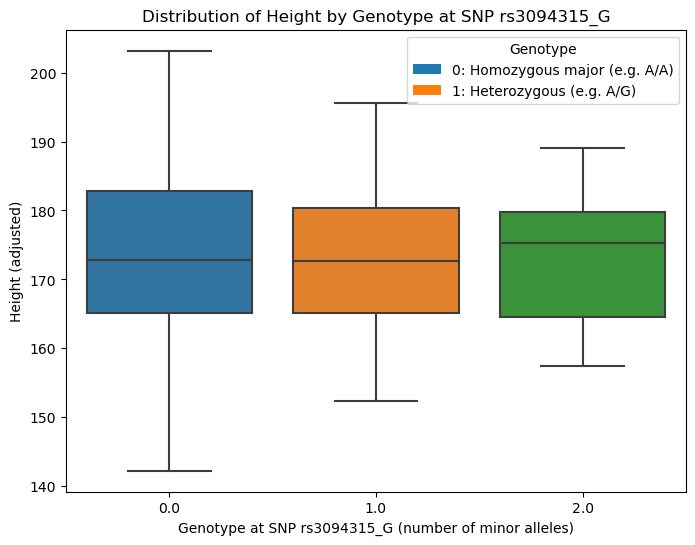

In [39]:
# Plot phenotype by genotype
plt.figure(figsize=(8,6))
sns.boxplot(x=snp_col, y="Height", data=merged)
plt.xlabel(f"Genotype at SNP {snp_col} (number of minor alleles)")
plt.ylabel("Height (adjusted)")
plt.title(f"Distribution of Height by Genotype at SNP {snp_col}")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=sns.color_palette()[0], label='0: Homozygous major (e.g. A/A)'),
    Patch(facecolor=sns.color_palette()[1], label='1: Heterozygous (e.g. A/G)')
]
plt.legend(handles=legend_elements, title="Genotype", loc='upper right')

plt.show()